<a href="https://colab.research.google.com/github/husthorng/Backpropagation_NN/blob/main/ANN_new_1141.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#https://drive.google.com/file/d/1DENGbC66jn0VJPkzSb0pjfWuRyvlz08j/view?usp=drive_link
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import auth
import gspread
from google.auth import default
auth.authenticate_user()

import numpy as np

def logistic(x):
    return 1 / (1 + np.exp(-x))

maxcycles = 90000
SSE_Goal = 0.1
lr = 0.001

SSE_log = []


creds, _ = default()
gc = gspread.authorize(creds)
#在雲端硬碟 建立速算表 cloud_data 工作表 data
#https://docs.google.com/spreadsheets/d/15kZWq3YmtF5yx40BRuz6TMGx0D22_r9QO-ea84BaRKQ/edit?gid=0#gid=0
sh = gc.open("cloud_data")
worksheet = sh.worksheet("data")

#data = worksheet.get_all_values()
data = worksheet.get_all_values()[1:]

data_np = np.array(data, dtype=float)

min_v = np.min(data_np, axis=0)
max_v = np.max(data_np, axis=0)

data_norm = (data_np - min_v) / (max_v - min_v)
x=data_norm[:,0:4]
t=data_norm[:,4:6]

X = np.hstack((x, np.ones((x.shape[0], 1))))
patterns,inputs  = x.shape
_, outputs = t.shape

hidden = 6

np.random.seed()

W1 = 0.5 * np.random.randn(inputs+1, hidden)
W2 = 0.5 * np.random.randn(hidden+1, outputs)

#下載W1W2.npz
#https://github.com/husthorng/Backpropagation_NN/blob/main/W1W2.npz
w=np.load("/content/drive/MyDrive/W1W2.npz")
W1 = w['W1']
W2 = w['W2']



fileID = open("/content/drive/MyDrive/exp.txt","w")

# ===============================
# Training Loop
# ===============================

for k in range(maxcycles):

  # forward
  h = logistic(X @ W1)
  H = np.hstack((h, np.ones((h.shape[0],1))))
  output = logistic(H @ W2)

  e = t - output
  SSE = np.sum(e**2)

  if k % 1000 == 0:
      eti = np.sum(e[0,:]**2)
      ete = np.sum(e[1,:]**2)
      print(f"Epoch={k}, SSE={SSE:.8f}")
      fileID.write(f"{k} {SSE:.8f} {eti:.8f} {ete:.8f}\n")

  if SSE < SSE_Goal:
      print("Goal reached")
      break

  # backprop
  delta2 = output * (1-output) * e
  W2 += 2 * lr * H.T @ delta2

  delta1 = h * (1-h) * (delta2 @ W2[:-1,:].T)
  W1 += 2 * lr * X.T @ delta1

fileID.close()
# Save model
np.savez("/content/drive/MyDrive/W1W2.npz", W1=W1, W2=W2, max_v=max_v, min_v=min_v)

print("Training Finished")
# ===============================
# Predict
# ===============================
h = logistic(X @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))
output = logistic(H @ W2)

# 反正規化
OV = output * (max_v - min_v)[4:6] + min_v[4:6]


Epoch=0, SSE=0.14713525
Epoch=1000, SSE=0.14712378
Epoch=2000, SSE=0.14711232
Epoch=3000, SSE=0.14710087
Epoch=4000, SSE=0.14708944
Epoch=5000, SSE=0.14707801
Epoch=6000, SSE=0.14706660
Epoch=7000, SSE=0.14705520
Epoch=8000, SSE=0.14704382
Epoch=9000, SSE=0.14703244
Epoch=10000, SSE=0.14702108
Epoch=11000, SSE=0.14700972
Epoch=12000, SSE=0.14699838
Epoch=13000, SSE=0.14698706
Epoch=14000, SSE=0.14697574
Epoch=15000, SSE=0.14696444
Epoch=16000, SSE=0.14695314
Epoch=17000, SSE=0.14694186
Epoch=18000, SSE=0.14693059
Epoch=19000, SSE=0.14691933
Epoch=20000, SSE=0.14690809
Epoch=21000, SSE=0.14689685
Epoch=22000, SSE=0.14688563
Epoch=23000, SSE=0.14687442
Epoch=24000, SSE=0.14686322
Epoch=25000, SSE=0.14685203
Epoch=26000, SSE=0.14684086
Epoch=27000, SSE=0.14682969
Epoch=28000, SSE=0.14681854
Epoch=29000, SSE=0.14680740
Epoch=30000, SSE=0.14679627
Epoch=31000, SSE=0.14678515
Epoch=32000, SSE=0.14677405
Epoch=33000, SSE=0.14676295
Epoch=34000, SSE=0.14675187
Epoch=35000, SSE=0.14674079
Epoch

In [7]:
real = data_np[:,4:6]

out_all = np.hstack((real, OV))

worksheet_out = sh.worksheet("output")

header = [["Ti_real","Te_real","Ti_pred","Te_pred"]]

#worksheet_out.clear()
worksheet_out.update("A1", header + out_all.tolist())

/tmp/ipykernel_172/4126951762.py:10: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet_out.update("A1", header + out_all.tolist())


{'spreadsheetId': '15kZWq3YmtF5yx40BRuz6TMGx0D22_r9QO-ea84BaRKQ',
 'updatedRange': 'output!A1:D371',
 'updatedRows': 371,
 'updatedColumns': 4,
 'updatedCells': 1484}

In [6]:
SSE_log.append(SSE)

In [5]:
try:
    ws_log = sh.worksheet("train_log")
except:
    ws_log = sh.add_worksheet(title="train_log", rows="1000", cols="10")

log_data = [[i, v] for i,v in enumerate(SSE_log)]

ws_log.clear()
ws_log.update("A1",[["epoch","SSE"]] + log_data)

/tmp/ipykernel_172/68557470.py:9: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  ws_log.update("A1",[["epoch","SSE"]] + log_data)


{'spreadsheetId': '15kZWq3YmtF5yx40BRuz6TMGx0D22_r9QO-ea84BaRKQ',
 'updatedRange': 'train_log!A1:B2',
 'updatedRows': 2,
 'updatedColumns': 2,
 'updatedCells': 4}

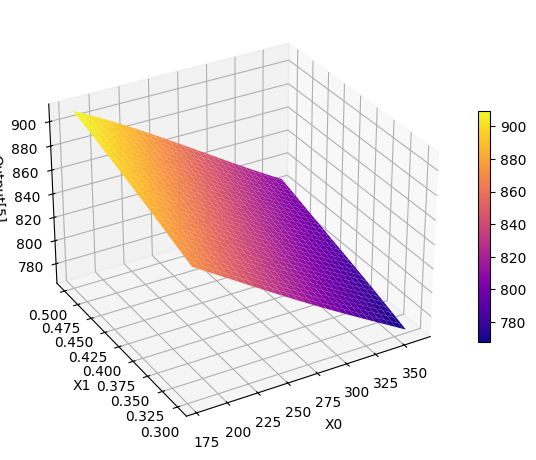

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -------------------------
# 建立 X0 X1 grid
# -------------------------

x0 = np.linspace(min_v[0], max_v[0], 60)
x1 = np.linspace(min_v[1], max_v[1], 60)

X0, X1 = np.meshgrid(x0, x1)

# 固定其他變數
x2 = np.mean(data_np[:,2])
x3 = np.mean(data_np[:,3])

# -------------------------
# 組成 NN input
# -------------------------

grid = np.zeros((X0.size,4))

grid[:,0] = X0.ravel()
grid[:,1] = X1.ravel()
grid[:,2] = x2
grid[:,3] = x3

# 正規化
grid_norm = (grid - min_v[0:4]) / (max_v[0:4] - min_v[0:4])

# 加 bias
Xg = np.hstack((grid_norm, np.ones((grid_norm.shape[0],1))))

# -------------------------
# NN Forward
# -------------------------

h = logistic(Xg @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))
out = logistic(H @ W2)

# 反正規化
OV = out * (max_v - min_v)[4:6] + min_v[4:6]

# 取第6欄 (index=1)
Z = OV[:,1].reshape(X0.shape)

# -------------------------
# 畫 3D surface
# -------------------------

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X0,
    X1,
    Z,
    cmap='plasma',
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("X0")
ax.set_ylabel("X1")
ax.set_zlabel("Output[5]")

fig.colorbar(surf, shrink=0.5)

ax.view_init(30, -120)

plt.show()